<a href="https://colab.research.google.com/github/abdullahalmusabbir/Deep-Learning-Project/blob/main/Butterfly_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Libraries**

In [1]:
import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

# **2. Setup Kaggle Import**

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("phucthaiv02/butterfly-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'butterfly-image-classification' dataset.
Path to dataset files: /kaggle/input/butterfly-image-classification


# **3. Import Data**

In [7]:
df = pd.read_csv(path + '/Training_set.csv')
display(df.head())

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


In [8]:
df.shape

(6499, 2)

In [9]:
df['label'].value_counts()

,count
label,
MOURNING CLOAK,131
SLEEPY ORANGE,107
ATALA,100
BROWN SIPROETA,99
SCARCE SWALLOW,97
...,...
AMERICAN SNOOT,74
GOLD BANDED,73
MALACHITE,73


In [10]:
df['label'].nunique()

75

# **3.2 Splitting Data**

In [11]:
train_data, val_data = train_test_split(df, test_size=0.2, random_state=42)

# **4. Data Preprocessing**

In [12]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)

In [15]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=path + '/train',
    x_col='filename',
    y_col='label',
    target_size=(256,256),
    batch_size=32,
    class_mode='categorical',
)

validation_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=path + '/train',
    x_col='filename',
    y_col='label',
    target_size=(256,256),
    batch_size=32,
    class_mode='categorical',
)

Found 5199 validated image filenames belonging to 75 classes.
Found 1300 validated image filenames belonging to 75 classes.


# **5.Visualizing Data**

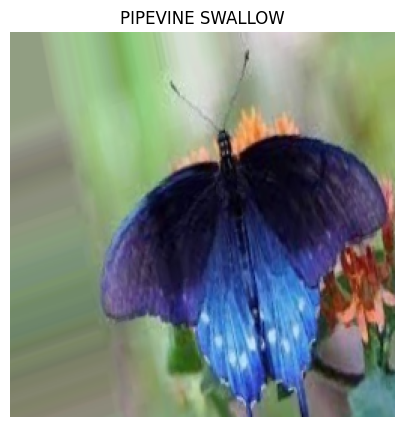

In [17]:
images, labels = next(train_generator)
class_names = {v: k for k, v in train_generator.class_indices.items()}

plt.figure(figsize=(5, 5))
plt.imshow(images[0])
label_index = np.argmax(labels[0])
label_name = class_names[label_index]
plt.title(f"{label_name}")
plt.axis('off')

plt.show()

# **6. CNN Model**

**6.1 Architecture**

In [18]:
model = tf.keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape = (256,256,3)),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(256, activation='relu'),
    # keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(75, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    29,491,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 75)             │        19,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,603,979 (112.93 MB)

 Trainable params: 29,603,979 (112.93 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
      optimizer=tf.keras.optimizers.Adam(),
      loss='categorical_crossentropy',
      metrics=['accuracy']
  )

# **6.2 Training**

In [22]:
model.fit(train_generator, epochs = 35, validation_data = validation_generator)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/35
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 647ms/step - accuracy: 0.0242 - loss: 4.2867 - val_accuracy: 0.1046 - val_loss: 3.6149
Epoch 2/35
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 524ms/step - accuracy: 0.1274 - loss: 3.4361 - val_accuracy: 0.3077 - val_loss: 2.5965
Epoch 3/35
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 511ms/step - accuracy: 0.2604 - loss: 2.7630 - val_accuracy: 0.3892 - val_loss: 2.2385
Epoch 4/35
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 518ms/step - accuracy: 0.3520 - loss: 2.3496 - val_accuracy: 0.4362 - val_loss: 2.0072
Epoch 5/35
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 518ms/step - accuracy: 0.4176 - loss: 2.1170 - val_accuracy: 0.4900 - val_loss: 1.9363
Epoch 6/35
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 511ms/step - accuracy: 0.4509 - loss: 1.9218 - val_accuracy: 0.5562 - val_loss: 1.6105
Epoch 7/35
163/163 ━━━━━━━━━━━━━━━━━━━━ 87s 536ms/step - accuracy: 0.4948 - loss: 1.7838 - val_accuracy: 0.5631 - val_loss: 1.5456
Epoch 8/35
163/163 ━━━━━━━━━━━━━━━━━━━━ 86s 527ms/step - accuracy: 0.5073 - loss: 

In [24]:
model.fit(train_generator, epochs = 40, initial_epoch = 35,validation_data = validation_generator)

Epoch 36/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 514ms/step - accuracy: 0.7840 - loss: 0.7153 - val_accuracy: 0.7323 - val_loss: 1.0963
Epoch 37/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 540ms/step - accuracy: 0.7871 - loss: 0.6778 - val_accuracy: 0.6969 - val_loss: 1.2569
Epoch 38/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 518ms/step - accuracy: 0.8042 - loss: 0.6118 - val_accuracy: 0.7115 - val_loss: 1.1337
Epoch 39/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 511ms/step - accuracy: 0.7927 - loss: 0.6731 - val_accuracy: 0.7323 - val_loss: 1.0930
Epoch 40/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 517ms/step - accuracy: 0.8043 - loss: 0.6376 - val_accuracy: 0.7300 - val_loss: 1.0892


In [25]:
model.fit(train_generator, epochs = 45, initial_epoch = 40,validation_data = validation_generator)

Epoch 41/45
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 524ms/step - accuracy: 0.8032 - loss: 0.6329 - val_accuracy: 0.7231 - val_loss: 1.1059
Epoch 42/45
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 513ms/step - accuracy: 0.8043 - loss: 0.6260 - val_accuracy: 0.7231 - val_loss: 1.0821
Epoch 43/45
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 512ms/step - accuracy: 0.8120 - loss: 0.5847 - val_accuracy: 0.7277 - val_loss: 1.0740
Epoch 44/45
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 509ms/step - accuracy: 0.8139 - loss: 0.5950 - val_accuracy: 0.7346 - val_loss: 1.0712
Epoch 45/45
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 512ms/step - accuracy: 0.8029 - loss: 0.6131 - val_accuracy: 0.7362 - val_loss: 1.0540


# **7. Model Evaluation**

In [26]:
loss, accuracy = model.evaluate(validation_generator)
print(f'Validation Loss: {loss:.4f}')
print(f'Validation Accuracy: {accuracy:.4f}')

41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.7307 - loss: 1.0311
Validation Loss: 1.0540
Validation Accuracy: 0.7362
